# CT-ICH Surface EDA


# 1. Environment

In [1]:
from pathlib import Path
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib
from IPython.display import display

IN_COLAB = 'google.colab' in sys.modules
print("Environment:", "Colab" if IN_COLAB else "Local")
print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("NiBabel:", nib.__version__)

Environment: Local
Python: 3.10.20
NumPy: 2.0.1
Pandas: 2.3.3
NiBabel: 5.4.2


# 2. Define paths


In [2]:
# 1. Kiểm tra môi trường thực thi
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)

    # path on drive
    DRIVE_PRJ_DIR = Path('/content/drive/MyDrive/self_research/brain_vlm_xai')
    DRIVE_DATA_RAW = DRIVE_PRJ_DIR / 'dataset_survey' / 'ICH-CT' / 'raw' / "ct-ich" / "1.3.1"

    # path on colab
    LOCAL_CACHE_DIR = Path('/content/data_cache/ICH-CT/raw')

    print("⚡ [Colab] Sync data to content")
    LOCAL_CACHE_DIR.mkdir(parents=True, exist_ok=True)
    !rsync -av --update "{DRIVE_DATA_RAW}/" "{LOCAL_CACHE_DIR}/"

    DATA_ROOT = LOCAL_CACHE_DIR

else:
    # Cấu trúc: brain_vlm_xai/notebooks/01_CT_ICH_Surface_EDA.ipynb
    PROJECT_ROOT = Path("..").resolve()
    DATA_ROOT = PROJECT_ROOT / "datasets" / "ICH-CT" / "raw" / "ct-ich" / "1.3.1"

CT_DIR = DATA_ROOT / "ct_scans"
MASK_DIR = DATA_ROOT / "masks"
DEMOGRAPHICS_FILE = DATA_ROOT / "Patient_demographics.csv"
SLICE_LABEL_FILE = DATA_ROOT / "hemorrhage_diagnosis_raw_ct.csv"

print("DATA_ROOT:", DATA_ROOT)
print("CT_DIR:", CT_DIR)
print("MASK_DIR:", MASK_DIR)
print("DEMOGRAPHICS_FILE:", DEMOGRAPHICS_FILE)
print("SLICE_LABEL_FILE:", SLICE_LABEL_FILE)

DATA_ROOT: D:\Research\brain_vlm_xai\datasets\ICH-CT\raw\ct-ich\1.3.1
CT_DIR: D:\Research\brain_vlm_xai\datasets\ICH-CT\raw\ct-ich\1.3.1\ct_scans
MASK_DIR: D:\Research\brain_vlm_xai\datasets\ICH-CT\raw\ct-ich\1.3.1\masks
DEMOGRAPHICS_FILE: D:\Research\brain_vlm_xai\datasets\ICH-CT\raw\ct-ich\1.3.1\Patient_demographics.csv
SLICE_LABEL_FILE: D:\Research\brain_vlm_xai\datasets\ICH-CT\raw\ct-ich\1.3.1\hemorrhage_diagnosis_raw_ct.csv


# 3. Minimal dataset check

In [3]:
paths = {
    "ct_scans": CT_DIR,
    "masks": MASK_DIR,
    "Patient_demographics.csv": DEMOGRAPHICS_FILE,
    "hemorrhage_diagnosis_raw_ct.csv": SLICE_LABEL_FILE,
}

for name, path in paths.items():
    print(f"[{'OK' if path.exists() else 'MISSING'}] {name}: {path}")

ct_files = sorted(list(CT_DIR.glob("*.nii")) + list(CT_DIR.glob("*.nii.gz")))
mask_files = sorted(list(MASK_DIR.glob("*.nii")) + list(MASK_DIR.glob("*.nii.gz")))

print()
print("CT volumes:", len(ct_files))
print("Mask volumes:", len(mask_files))

[OK] ct_scans: D:\Research\brain_vlm_xai\datasets\ICH-CT\raw\ct-ich\1.3.1\ct_scans
[OK] masks: D:\Research\brain_vlm_xai\datasets\ICH-CT\raw\ct-ich\1.3.1\masks
[OK] Patient_demographics.csv: D:\Research\brain_vlm_xai\datasets\ICH-CT\raw\ct-ich\1.3.1\Patient_demographics.csv
[OK] hemorrhage_diagnosis_raw_ct.csv: D:\Research\brain_vlm_xai\datasets\ICH-CT\raw\ct-ich\1.3.1\hemorrhage_diagnosis_raw_ct.csv

CT volumes: 75
Mask volumes: 75


# 4. Dataset Card — hiểu dataset trước

In [4]:
dataset_card = {
    "dataset": "CT-ICH v1.3.1",
    "clinical_problem": "Traumatic brain injury with intracranial hemorrhage",
    "modality": "Non-contrast head CT",
    "representation": "3D NIfTI volume / axial slices",
    "parent_task": "Intracranial hemorrhage assessment",
    "subtasks": [
        "slice-level ICH/subtype classification",
        "patient/scan-level overview derived from slice labels",
        "lesion segmentation/localization",
        "skull-fracture label (auxiliary)",
    ],
    "subtypes": ["IVH", "IPH", "SAH", "EDH", "SDH"],
    "paired_report_or_QA": False,
}

display(pd.Series(dataset_card, name="CT-ICH"))

dataset                                                    CT-ICH v1.3.1
clinical_problem       Traumatic brain injury with intracranial hemor...
modality                                            Non-contrast head CT
representation                            3D NIfTI volume / axial slices
parent_task                           Intracranial hemorrhage assessment
subtasks               [slice-level ICH/subtype classification, patie...
subtypes                                       [IVH, IPH, SAH, EDH, SDH]
paired_report_or_QA                                                False
Name: CT-ICH, dtype: object

## Task hierarchy

```text
Parent problem
└── Intracranial hemorrhage assessment in TBI head CT
    ├── ICH / subtype classification (Intracranial Hemorrhage - Xuất huyết nội sọ)
    │   ├── IVH (Intraventricular Hemorrhage - Xuất huyết não thất)
    │   ├── IPH (Intraparenchymal Hemorrhage - Xuất huyết nội nhu mô)
    │   ├── SAH (Subarachnoid Hemorrhage - Xuất huyết khoang dưới nhện)
    │   ├── EDH (Epidural Hemorrhage - Xuất huyết ngoài màng cứng)
    │   └── SDH (Subdural Hemorrhage - Xuất huyết dưới màng cứng)
    ├── slice-level classification
    ├── lesion segmentation / localization
    └── fracture (auxiliary) (phát hiện nứt vỡ xương sọ)
```


# 5. Load tabular data

In [5]:
demo = pd.read_csv(DEMOGRAPHICS_FILE)
slice_labels = pd.read_csv(SLICE_LABEL_FILE)

print("Demographics shape:", demo.shape)
print("Slice-label shape:", slice_labels.shape)

print()
print("Demographics columns:")
print(demo.columns.tolist())

print()
print("Slice-label columns:")
print(slice_labels.columns.tolist())

print()
print("Demographics preview:")
display(demo.head())

print("Slice-label preview:")
display(slice_labels.head())

Demographics shape: (85, 10)
Slice-label shape: (2814, 9)

Demographics columns:
['Patient Number', 'Age\n(years)', 'Gender', 'Hemorrhage type based on the radiologists diagnosis ', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Fracture (yes 1/no 0)', 'Note1']

Slice-label columns:
['PatientNumber', 'SliceNumber', 'Intraventricular', 'Intraparenchymal', 'Subarachnoid', 'Epidural', 'Subdural', 'No_Hemorrhage', 'Fracture_Yes_No']

Demographics preview:


,Patient Number,Age\n(years),Gender,Hemorrhage type based on the radiologists diagnosis,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Fracture (yes 1/no 0),Note1
0,NaN,NaN,NaN,Intraventricular,Intraparenchymal,Subarachnoid,Epidural,Subdural,NaN,NaN
1,49.0,35.000,Male,NaN,1,NaN,1,NaN,1.0,NaN
2,50.0,0.583,Female,NaN,1,NaN,NaN,NaN,1.0,NaN
3,51.0,5.000,Male,NaN,1,NaN,NaN,1,1.0,NaN
4,52.0,8.000,Male,NaN,NaN,NaN,1,NaN,1.0,NaN


Slice-label preview:


,PatientNumber,SliceNumber,Intraventricular,Intraparenchymal,Subarachnoid,Epidural,Subdural,No_Hemorrhage,Fracture_Yes_No
0,49,1,0,0,0,0,0,1,0
1,49,2,0,0,0,0,0,1,0
2,49,3,0,0,0,0,0,1,0
3,49,4,0,0,0,0,0,1,0
4,49,5,0,0,0,0,0,1,0


# 6. Simple schema EDA

In [6]:
def schema_report(df):
    data = {
        "dtype": df.dtypes.astype(str),
        "missing": df.isna().sum(),
        "nunique": df.nunique(dropna=False)
    }

    unique_col_data = []
    for col in df.columns:
        col_series = df[col]
        if col_series.nunique(dropna=False) < 10:
            unique_col_data.append(str(col_series.unique().tolist()))
        else:
            unique_col_data.append("")

    data["unique"] = pd.Series(unique_col_data, index=df.columns)

    return pd.DataFrame(data)

print("=== Demographics schema ===")
display(schema_report(demo))

print("=== Slice-label schema ===")
display(schema_report(slice_labels))

print("Duplicate full rows:")
print("demographics:", int(demo.duplicated().sum()))
print("slice labels:", int(slice_labels.duplicated().sum()))

=== Demographics schema ===


,dtype,missing,nunique,unique
Patient Number,float64,3,83,
Age\n(years),float64,1,46,
Gender,object,1,5,"[nan, 'Male', 'Female', '46', '36']"
Hemorrhage type based on the radiologists diagnosis,object,79,3,"['Intraventricular ', nan, '1']"
Unnamed: 4,object,68,3,"['Intraparenchymal', '1', nan]"
Unnamed: 5,object,77,3,"['Subarachnoid', nan, '1']"
Unnamed: 6,object,63,3,"['Epidural', '1', nan]"
Unnamed: 7,object,80,3,"['Subdural', nan, '1']"
Fracture (yes 1/no 0),float64,63,2,"[nan, 1.0]"
Note1,object,84,2,"[nan, 'Special case, CT scan was after about t..."


=== Slice-label schema ===


,dtype,missing,nunique,unique
PatientNumber,int64,0,75,
SliceNumber,int64,0,58,
Intraventricular,int64,0,2,"[0, 1]"
Intraparenchymal,int64,0,2,"[0, 1]"
Subarachnoid,int64,0,2,"[0, 1]"
Epidural,int64,0,2,"[0, 1]"
Subdural,int64,0,2,"[0, 1]"
No_Hemorrhage,int64,0,2,"[1, 0]"
Fracture_Yes_No,int64,0,2,"[0, 1]"


Duplicate full rows:
demographics: 0
slice labels: 0


### Demographics CSV: extra header and footer rows

The schema contains unexpected values in `Gender` and subtype columns. Inspecting the raw CSV below identifies a second header and summary-footer rows; use the cleaned patient table for demographic statistics.

In [7]:
# Raw, header-free peek to see how the file is actually laid out
raw_head = pd.read_csv(DEMOGRAPHICS_FILE, header=None, nrows=5)
display(raw_head)

# Isolate the rows responsible for the odd Gender values
# (using the literal column name here since DEMO_GENDER is defined later, in section 7)
bad_gender = demo[demo["Gender"].notna() & ~demo["Gender"].isin(["Male", "Female"])]
print("Rows with unexpected Gender values:")
display(bad_gender)


,0,1,2,3,4,5,6,7,8,9
0,Patient Number,Age\n(years),Gender,Hemorrhage type based on the radiologists diag...,NaN,NaN,NaN,NaN,Fracture (yes 1/no 0),Note1
1,NaN,NaN,NaN,Intraventricular,Intraparenchymal,Subarachnoid,Epidural,Subdural,NaN,NaN
2,49,35,Male,NaN,1,NaN,1,NaN,1,NaN
3,50,0.583,Female,NaN,1,NaN,NaN,NaN,1,NaN
4,51,5,Male,NaN,1,NaN,NaN,1,1,NaN


Rows with unexpected Gender values:


,Patient Number,Age\n(years),Gender,Hemorrhage type based on the radiologists diagnosis,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Fracture (yes 1/no 0),Note1
83,NaN,27.843733,46,NaN,NaN,NaN,NaN,NaN,NaN,NaN
84,NaN,19.520890,36,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Root cause confirmed from the outputs above:**

1. `raw_head` shows the CSV has a real header on row 0 and a **second header row** right below it
   (`Intraventricular`, `Intraparenchymal`, ... in the hemorrhage-type columns). `pd.read_csv` only
   treated row 0 as header, so that second header row was read in as **data** — this is the phantom
   record with `Patient Number = NaN` that pollutes both the demographics schema and the subtype columns.
2. `bad_gender` shows two more phantom rows at the bottom (`Gender = '46'`, `'36'`, with `Patient Number`
   = NaN and `Age` = 27.84 / 19.52). These numbers are not real patient data — `'46'`/`'36'` exactly match
   the **Male/Female patient counts** from the Gender distribution in section 10, and 27.84 / 19.52 are
   the **mean age per gender group**. A summary footer (count + mean age by gender) was appended to the
   bottom of the CSV without a separator and got parsed as two extra patient rows.

Net effect: of the 85 rows in `demo`, 3 are not real patients (1 phantom header row + 2 summary-footer
rows) → 82 real patient records.

# 7. Labels — dùng đúng schema hiện tại

Với file bạn đang có:

**Demographics**
- `Patient Number`
- `Gender`
- không có 5 subtype columns trong file này

**Slice labels**
- `PatientNumber`
- `SliceNumber`
- `Intraventricular`
- `Intraparenchymal`
- `Subarachnoid`
- `Epidural`
- `Subdural`
- `Fracture_Yes_No`


In [8]:
DEMO_PATIENT = "Patient Number"
DEMO_GENDER = "Gender"

SLICE_PATIENT = "PatientNumber"
SLICE_NUMBER = "SliceNumber"

LABEL_COLUMNS = {
    "IVH": "Intraventricular",
    "IPH": "Intraparenchymal",
    "SAH": "Subarachnoid",
    "EDH": "Epidural",
    "SDH": "Subdural",
}

FRACTURE_COLUMN = "Fracture_Yes_No"

expected_demo = [DEMO_PATIENT, DEMO_GENDER]
expected_slice = [SLICE_PATIENT, SLICE_NUMBER, *LABEL_COLUMNS.values(), FRACTURE_COLUMN]

print("Missing expected demographics columns:", [c for c in expected_demo if c not in demo.columns])
print("Missing expected slice columns:", [c for c in expected_slice if c not in slice_labels.columns])

Missing expected demographics columns: []
Missing expected slice columns: []


In [9]:
demo_clean = demo.drop(index=[0, 83, 84]).copy()
demo_clean[DEMO_PATIENT] = pd.to_numeric(demo_clean[DEMO_PATIENT], errors="coerce")

print("Rows before / after cleaning:", len(demo), "/", len(demo_clean))
print()
print("Gender distribution (cleaned):")
display(demo_clean[DEMO_GENDER].value_counts(dropna=False).rename("patients").to_frame())

age_clean = pd.to_numeric(demo_clean["Age\n(years)"], errors="coerce").dropna()
print()
print("Age summary (cleaned):")
display(age_clean.describe().to_frame("Age"))

Rows before / after cleaning: 85 / 82

Gender distribution (cleaned):


,patients
Gender,
Male,46
Female,36



Age summary (cleaned):


,Age
count,82.000000
mean,27.843720
std,19.520909
min,0.002000
25%,11.250000
50%,26.000000
75%,40.000000
max,72.000000


**Also worth checking now:** `demo` has 82 real patients (after cleaning) but there are only 75 CT
volumes (`ct_files`). Confirm whether this is expected (some patients have no scan / some scans have no
demographics row) before using `demo_clean` for anything joined to imaging data.

In [12]:
def patient_id_from_file(path):
    name = path.name
    if name.endswith(".nii.gz"):
        return name[:-7]
    if name.endswith(".nii"):
        return name[:-4]
    return path.stem

In [13]:
demo_ids = set(demo_clean[DEMO_PATIENT].dropna().astype(int).astype(str).str.zfill(3))
ct_ids = set(patient_id_from_file(p) for p in ct_files)

print("Patients in demographics:", len(demo_ids))
print("Patients with a CT volume:", len(ct_ids))
print("In demographics but no CT volume:", sorted(demo_ids - ct_ids))
print("Have CT volume but no demographics row:", sorted(ct_ids - demo_ids))

Patients in demographics: 82
Patients with a CT volume: 75
In demographics but no CT volume: ['059', '060', '061', '062', '063', '064', '065']
Have CT volume but no demographics row: []


# 8. Label EDA — slice level

Đây là phần quan trọng nhất để xác nhận label có thực sự được đọc đúng.

In [14]:
label_table = pd.DataFrame({
    name: pd.to_numeric(slice_labels[column], errors="coerce")
    for name, column in LABEL_COLUMNS.items()
})

print("Positive slice counts:")
display(label_table.sum().sort_values(ascending=False).rename("positive_slices").to_frame())

print()
print("Unique values in each label column:")
for name, column in LABEL_COLUMNS.items():
    print(name, "->", slice_labels[column].dropna().unique())

Positive slice counts:


,positive_slices
EDH,173
IPH,73
SDH,56
IVH,24
SAH,18



Unique values in each label column:
IVH -> [0 1]
IPH -> [0 1]
SAH -> [0 1]
EDH -> [0 1]
SDH -> [0 1]


### 8b. Multi-label overlap — can one slice have multiple positive subtypes?


In [15]:
# NaN -> 0 here is local to this overlap count only; it does not change label_table itself
label_binary = (label_table.fillna(0) > 0).astype(int)
n_labels_per_slice = label_binary.sum(axis=1)

print("Distribution of number of positive subtypes per slice:")
display(n_labels_per_slice.value_counts().sort_index().rename("num_slices").to_frame())

print()
print("Slices with >1 positive subtype:", int((n_labels_per_slice > 1).sum()))


Distribution of number of positive subtypes per slice:


,num_slices
0,2496
1,293
2,24
3,1



Slices with >1 positive subtype: 25


# 9. Patient-level label overview — derived, not original

In [16]:
slice_work = slice_labels[[SLICE_PATIENT, SLICE_NUMBER, *LABEL_COLUMNS.values()]].copy()

for col in LABEL_COLUMNS.values():
    slice_work[col] = pd.to_numeric(slice_work[col], errors="coerce").fillna(0)

patient_labels = (
    slice_work.groupby(SLICE_PATIENT)[list(LABEL_COLUMNS.values())]
    .max()
    .rename(columns={value: key for key, value in LABEL_COLUMNS.items()})
)

patient_labels["ICH_any"] = (patient_labels[list(LABEL_COLUMNS.keys())].sum(axis=1) > 0).astype(int)

print("Derived patient-level subtype counts:")
display(patient_labels[list(LABEL_COLUMNS.keys())].sum().sort_values(ascending=False).rename("positive_patients").to_frame())

print()
print("Patients with any ICH:", int(patient_labels["ICH_any"].sum()))
print("Patients represented in slice labels:", len(patient_labels))

Derived patient-level subtype counts:


,positive_patients
EDH,21
IPH,16
SAH,7
IVH,5
SDH,4



Patients with any ICH: 36
Patients represented in slice labels: 75


**Design note:** the `fillna(0)` two cells above is a deliberate choice scoped to *patient-level aggregation only* — a missing subtype value at the slice level is treated as "not positive for this subtype" when computing whether a patient has *any* occurrence of a subtype across their slices. It does not overwrite the slice-level values used in the Label EDA section above, where missing values stay `NaN` and are reported as such.


# 11. Image metadata — shape, dtype, spacing, orientation

In [18]:
from nibabel.orientations import aff2axcodes

image_records = []

for path in ct_files:
    try:
        img = nib.load(path)
        image_records.append({
            "patient_id": patient_id_from_file(path),
            "shape": tuple(img.shape),
            "dtype": str(img.get_data_dtype()),
            "spacing": tuple(img.header.get_zooms()[:3]),
            "orientation": "".join(aff2axcodes(img.affine)),
        })
    except Exception as e:
        image_records.append({
            "patient_id": patient_id_from_file(path),
            "error": str(e),
        })

image_meta = pd.DataFrame(image_records)

display(image_meta.head())

print()
print("Shape frequencies:")
display(image_meta["shape"].value_counts().rename("volumes").to_frame().head(15))

print("Dtype frequencies:")
display(image_meta["dtype"].value_counts(dropna=False).rename("volumes").to_frame())

print("Orientation frequencies:")
display(image_meta["orientation"].value_counts(dropna=False).rename("volumes").to_frame())

,patient_id,shape,dtype,spacing,orientation
0,049,"(512, 512, 39)",int16,"(0.41210938, 0.41210938, 5.0)",LAS
1,050,"(512, 512, 32)",int16,"(0.3515625, 0.3515625, 5.0)",LAS
2,051,"(512, 512, 46)",int16,"(0.41210938, 0.41210938, 5.0)",LAS
3,052,"(512, 512, 35)",int16,"(0.390625, 0.390625, 5.0)",LAS
4,053,"(512, 512, 35)",int16,"(0.47265625, 0.47265625, 5.0)",LAS



Shape frequencies:


,volumes
shape,
"(512, 512, 33)",10
"(512, 512, 37)",10
"(512, 512, 35)",9
"(512, 512, 34)",8
"(512, 512, 36)",7
"(512, 512, 32)",5
"(512, 512, 39)",4
"(512, 512, 38)",4
"(512, 512, 40)",4


Dtype frequencies:


,volumes
dtype,
int16,75


Orientation frequencies:


,volumes
orientation,
LAS,75


# 12. Voxel spacing

In [19]:
spacing_df = pd.DataFrame(
    image_meta["spacing"].tolist(),
    columns=["sx_mm", "sy_mm", "sz_mm"]
)

display(spacing_df.describe())

,sx_mm,sy_mm,sz_mm
count,75.000000,75.000000,75.0
mean,0.422344,0.422344,5.0
std,0.029629,0.029629,0.0
min,0.314453,0.314453,5.0
25%,0.408203,0.408203,5.0
50%,0.421875,0.421875,5.0
75%,0.443359,0.443359,5.0
max,0.488281,0.488281,5.0


# 13. One CT visualization + intensity

Sample: 076.nii
Shape: (512, 512, 51)
Stored dtype: int16
Min: -1024.0
Max: 3071.0


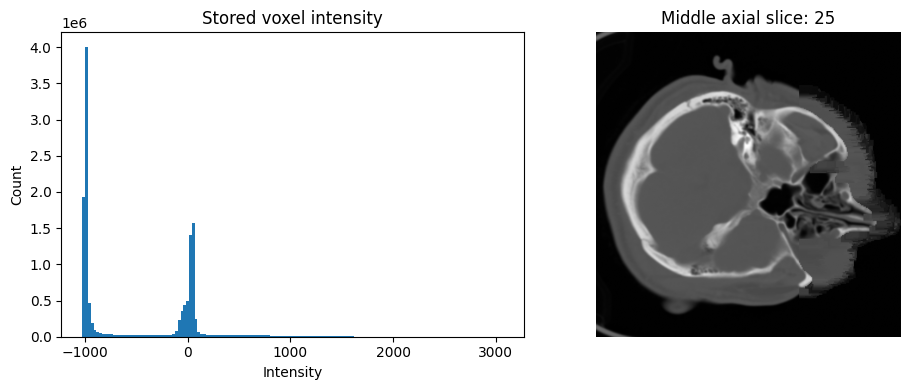

In [20]:
sample_path = ct_files[20]
sample_img = nib.load(sample_path)
sample_ct = sample_img.get_fdata()

print("Sample:", sample_path.name)
print("Shape:", sample_ct.shape)
print("Stored dtype:", sample_img.get_data_dtype())
print("Min:", float(np.nanmin(sample_ct)))
print("Max:", float(np.nanmax(sample_ct)))

mid = sample_ct.shape[2] // 2

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(sample_ct.ravel(), bins=150)
axes[0].set_title("Stored voxel intensity")
axes[0].set_xlabel("Intensity")
axes[0].set_ylabel("Count")

axes[1].imshow(sample_ct[:, :, mid], cmap="gray")
axes[1].set_title(f"Middle axial slice: {mid}")
axes[1].axis("off")

plt.tight_layout()
plt.show()

**Important:** histogram trên là histogram của **stored NIfTI values**. Chưa gọi chúng là HU nếu chưa xác nhận representation.

# 14. Mask / spatial annotation

In [21]:
def find_mask(ct_path):
    candidate = MASK_DIR / ct_path.name
    if candidate.exists():
        return candidate

    if ct_path.name.endswith(".nii.gz"):
        candidate = MASK_DIR / ct_path.name[:-3]
    else:
        candidate = MASK_DIR / (ct_path.stem + ".nii.gz")

    return candidate if candidate.exists() else None

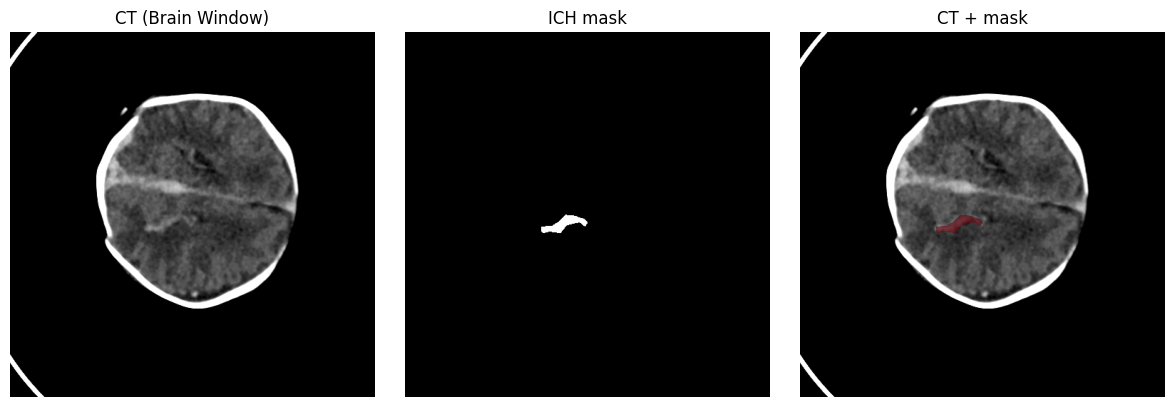

CT shape: (512, 512, 34)
Mask shape: (512, 512, 34)
Shape match: True
Spacing match: True
Mask unique values: [  0.         254.99999994]
CT slice min/max (raw): -1005.0 1105.0


In [ ]:
example = None
target_sample_idx = 25  
count = 0

for ct_path in ct_files:
    mask_path = find_mask(ct_path)
    if mask_path is None:
        continue

    mask = nib.load(mask_path).get_fdata()
    if np.any(mask > 0):
        if count == target_sample_idx:
            example = (ct_path, mask_path, mask)
            break
        count += 1

if example is None:
    print("No readable non-empty mask found.")
else:
    ct_path, mask_path, mask = example
    ct_img = nib.load(ct_path)
    ct = ct_img.get_fdata()
    mask_img = nib.load(mask_path)

    # Tìm slice giữa chứa tổn thương
    lesion_slices = np.where(np.any(mask > 0, axis=(0, 1)))[0]
    idx = int(lesion_slices[len(lesion_slices) // 2])

    slice_ct = ct[:, :, idx]
    slice_mask = mask[:, :, idx]

    # Thiết lập cửa sổ hiển thị (Brain Window chuẩn cho đơn vị Hounsfield HU: Level = 40, Width = 80)
    # Nếu dữ liệu của bạn đã được chuẩn hóa (ví dụ về [0, 1]), hãy điều chỉnh lại vmin và vmax tương ứng.
    WINDOW_MIN, WINDOW_MAX = 0, 80

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    
    # 1. Ảnh CT gốc với Brain Window
    axes[0].imshow(slice_ct, cmap="gray", vmin=WINDOW_MIN, vmax=WINDOW_MAX)
    axes[0].set_title("CT (Brain Window)")

    # 2. Ảnh Mask
    axes[1].imshow(slice_mask, cmap="gray")
    axes[1].set_title("ICH mask")

    # 3. Chồng CT và Mask với colormap nổi bật ('Reds')
    axes[2].imshow(slice_ct, cmap="gray", vmin=WINDOW_MIN, vmax=WINDOW_MAX)
    masked_overlay = np.ma.masked_where(slice_mask == 0, slice_mask)
    axes[2].imshow(masked_overlay, cmap="Reds", alpha=0.6, vmin=0, vmax=1)
    axes[2].set_title("CT + mask")

    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

    # In thông tin kiểm tra
    print("CT shape:", ct.shape)
    print("Mask shape:", mask.shape)
    print("Shape match:", ct.shape == mask.shape)
    print("Spacing match:", np.allclose(ct_img.header.get_zooms()[:3], mask_img.header.get_zooms()[:3]))
    print("Mask unique values:", np.unique(mask))
    print("CT slice min/max (raw):", slice_ct.min(), slice_ct.max())

# Research summary

- **Task:** multi-label classification of five ICH subtypes and an auxiliary fracture label at slice level, plus hemorrhage localization using paired masks. Patient labels shown here are derived by taking the maximum over a patient's slices.
- **Released imaging data:** 75 non-contrast CT volumes and 75 NIfTI masks; 2,814 slice-label rows. CT volumes are 512 × 512 × variable depth, with 5 mm slice spacing in this release. The inspected CT–mask pair had matching shape and spacing; full-pair alignment has not been audited.
- **Class balance:** EDH is the most frequent positive slice subtype (173); SAH (18) and IVH (24) are rare. Twenty-five slices have multiple positive subtypes.
- **Demographics:** after excluding one extra header and two footer rows, the CSV has 82 patient records, of which 75 have released CT volumes. Use `demo_clean`, not the later raw `demo` count, for age or gender summaries.
- **Research use:** hemorrhage masks permit spatial evaluation of segmentation or saliency overlap. No paired report or QA text is provided. Such overlap measures should be interpreted with the underlying label and mask quality in mind.
